In [1]:


import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


In [3]:
np.random.seed(42)

tf.random.set_seed(42)

In [4]:
# Load Breast Cancer Dataset

data = load_breast_cancer()

X = data.data

y = data.target

feature_names = data.feature_names

In [5]:
df = pd.DataFrame(X, columns=feature_names)

df["Target"] = y

In [6]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [7]:
print("Rows :", df.shape[0])

print("Columns :", df.shape[1])

Rows : 569
Columns : 31


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [10]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [11]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [12]:
df["Target"].value_counts()

,count
Target,
1,357
0,212


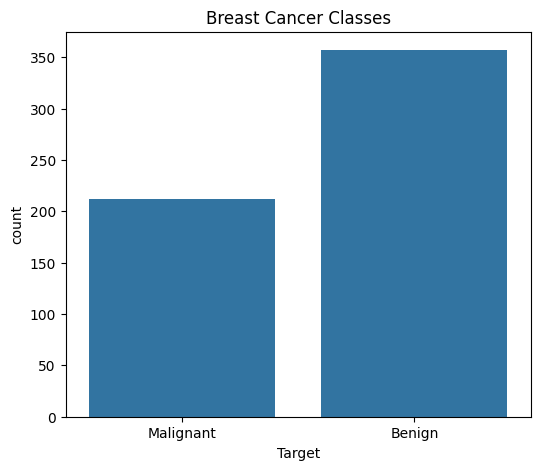

In [13]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Target")

plt.title("Breast Cancer Classes")

plt.xticks([0,1],["Malignant","Benign"])

plt.show()

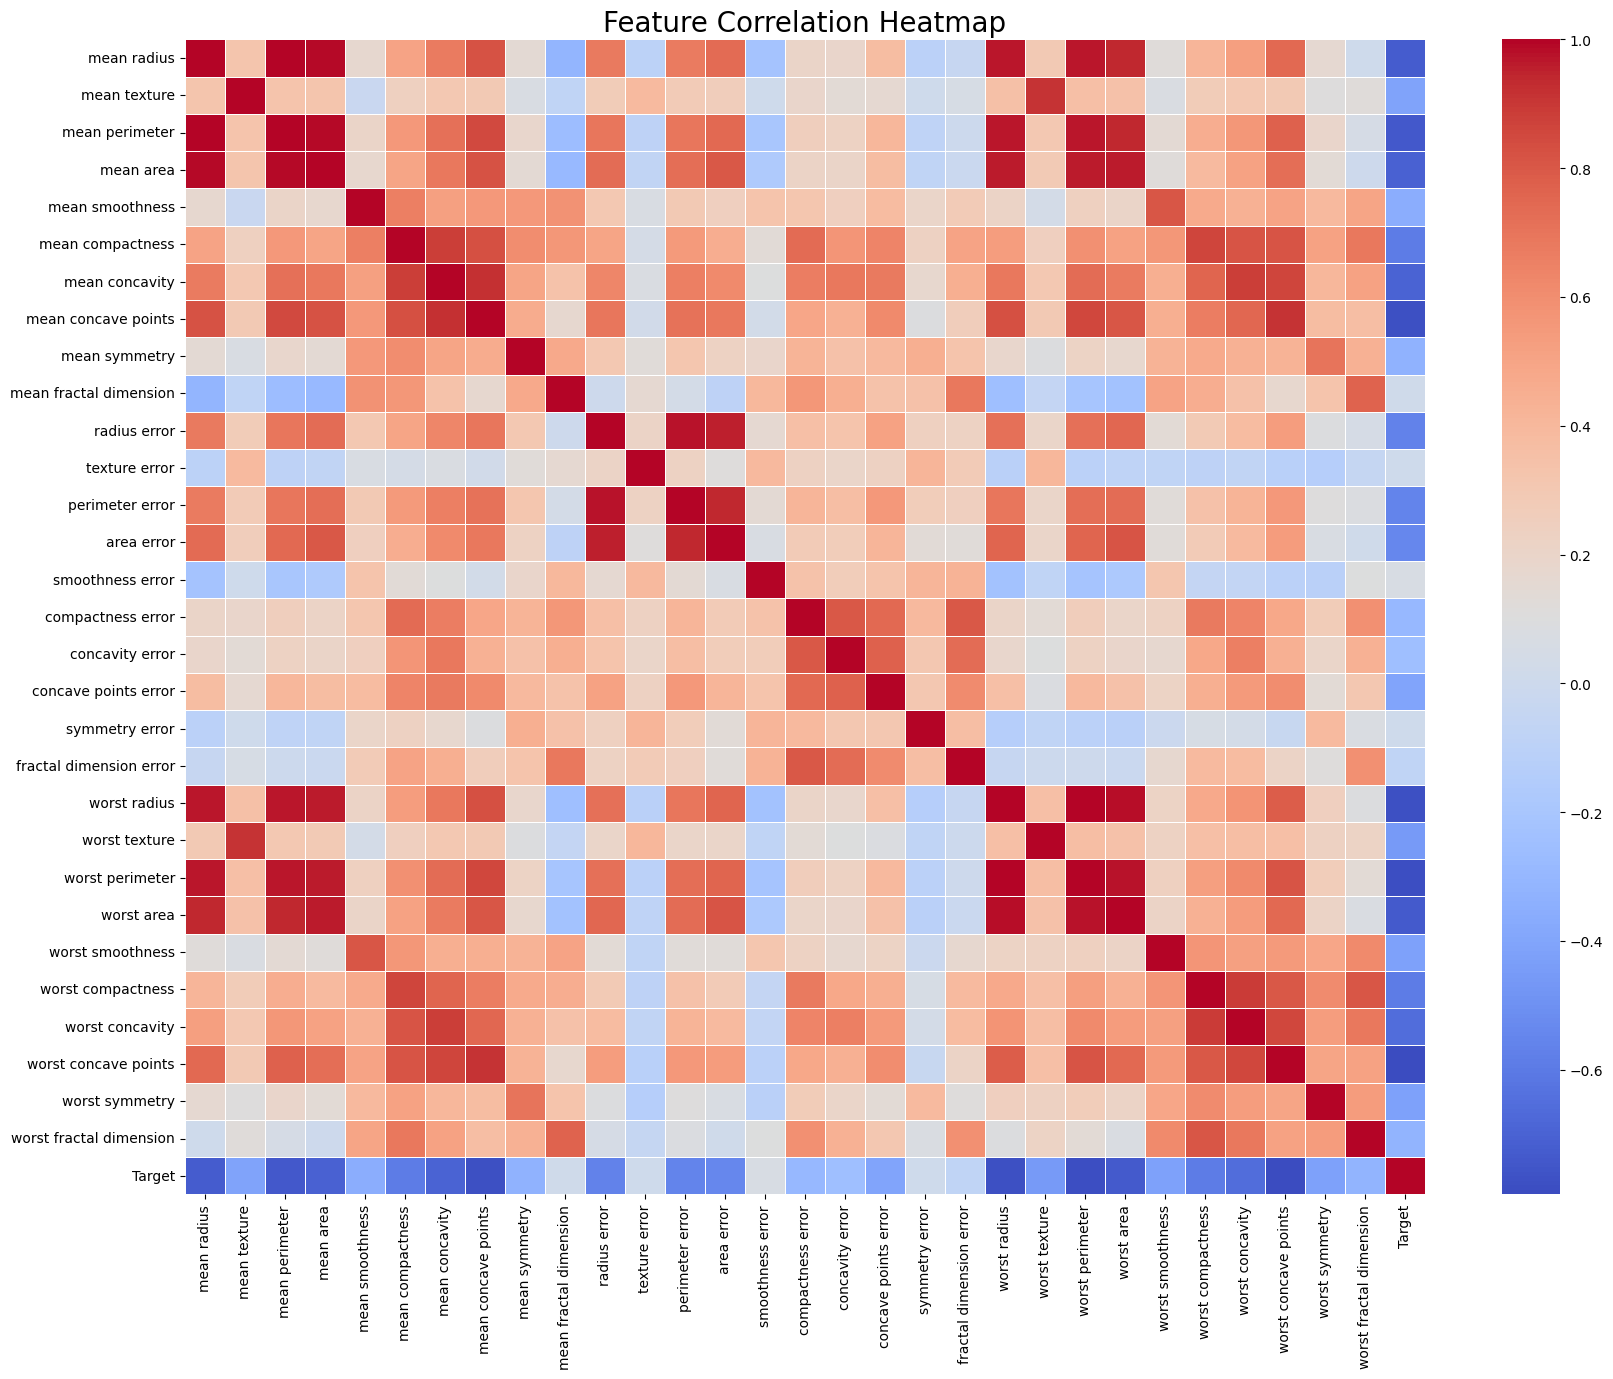

In [14]:

# Correlation Heatmap


plt.figure(figsize=(20,15))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=20)

plt.show()

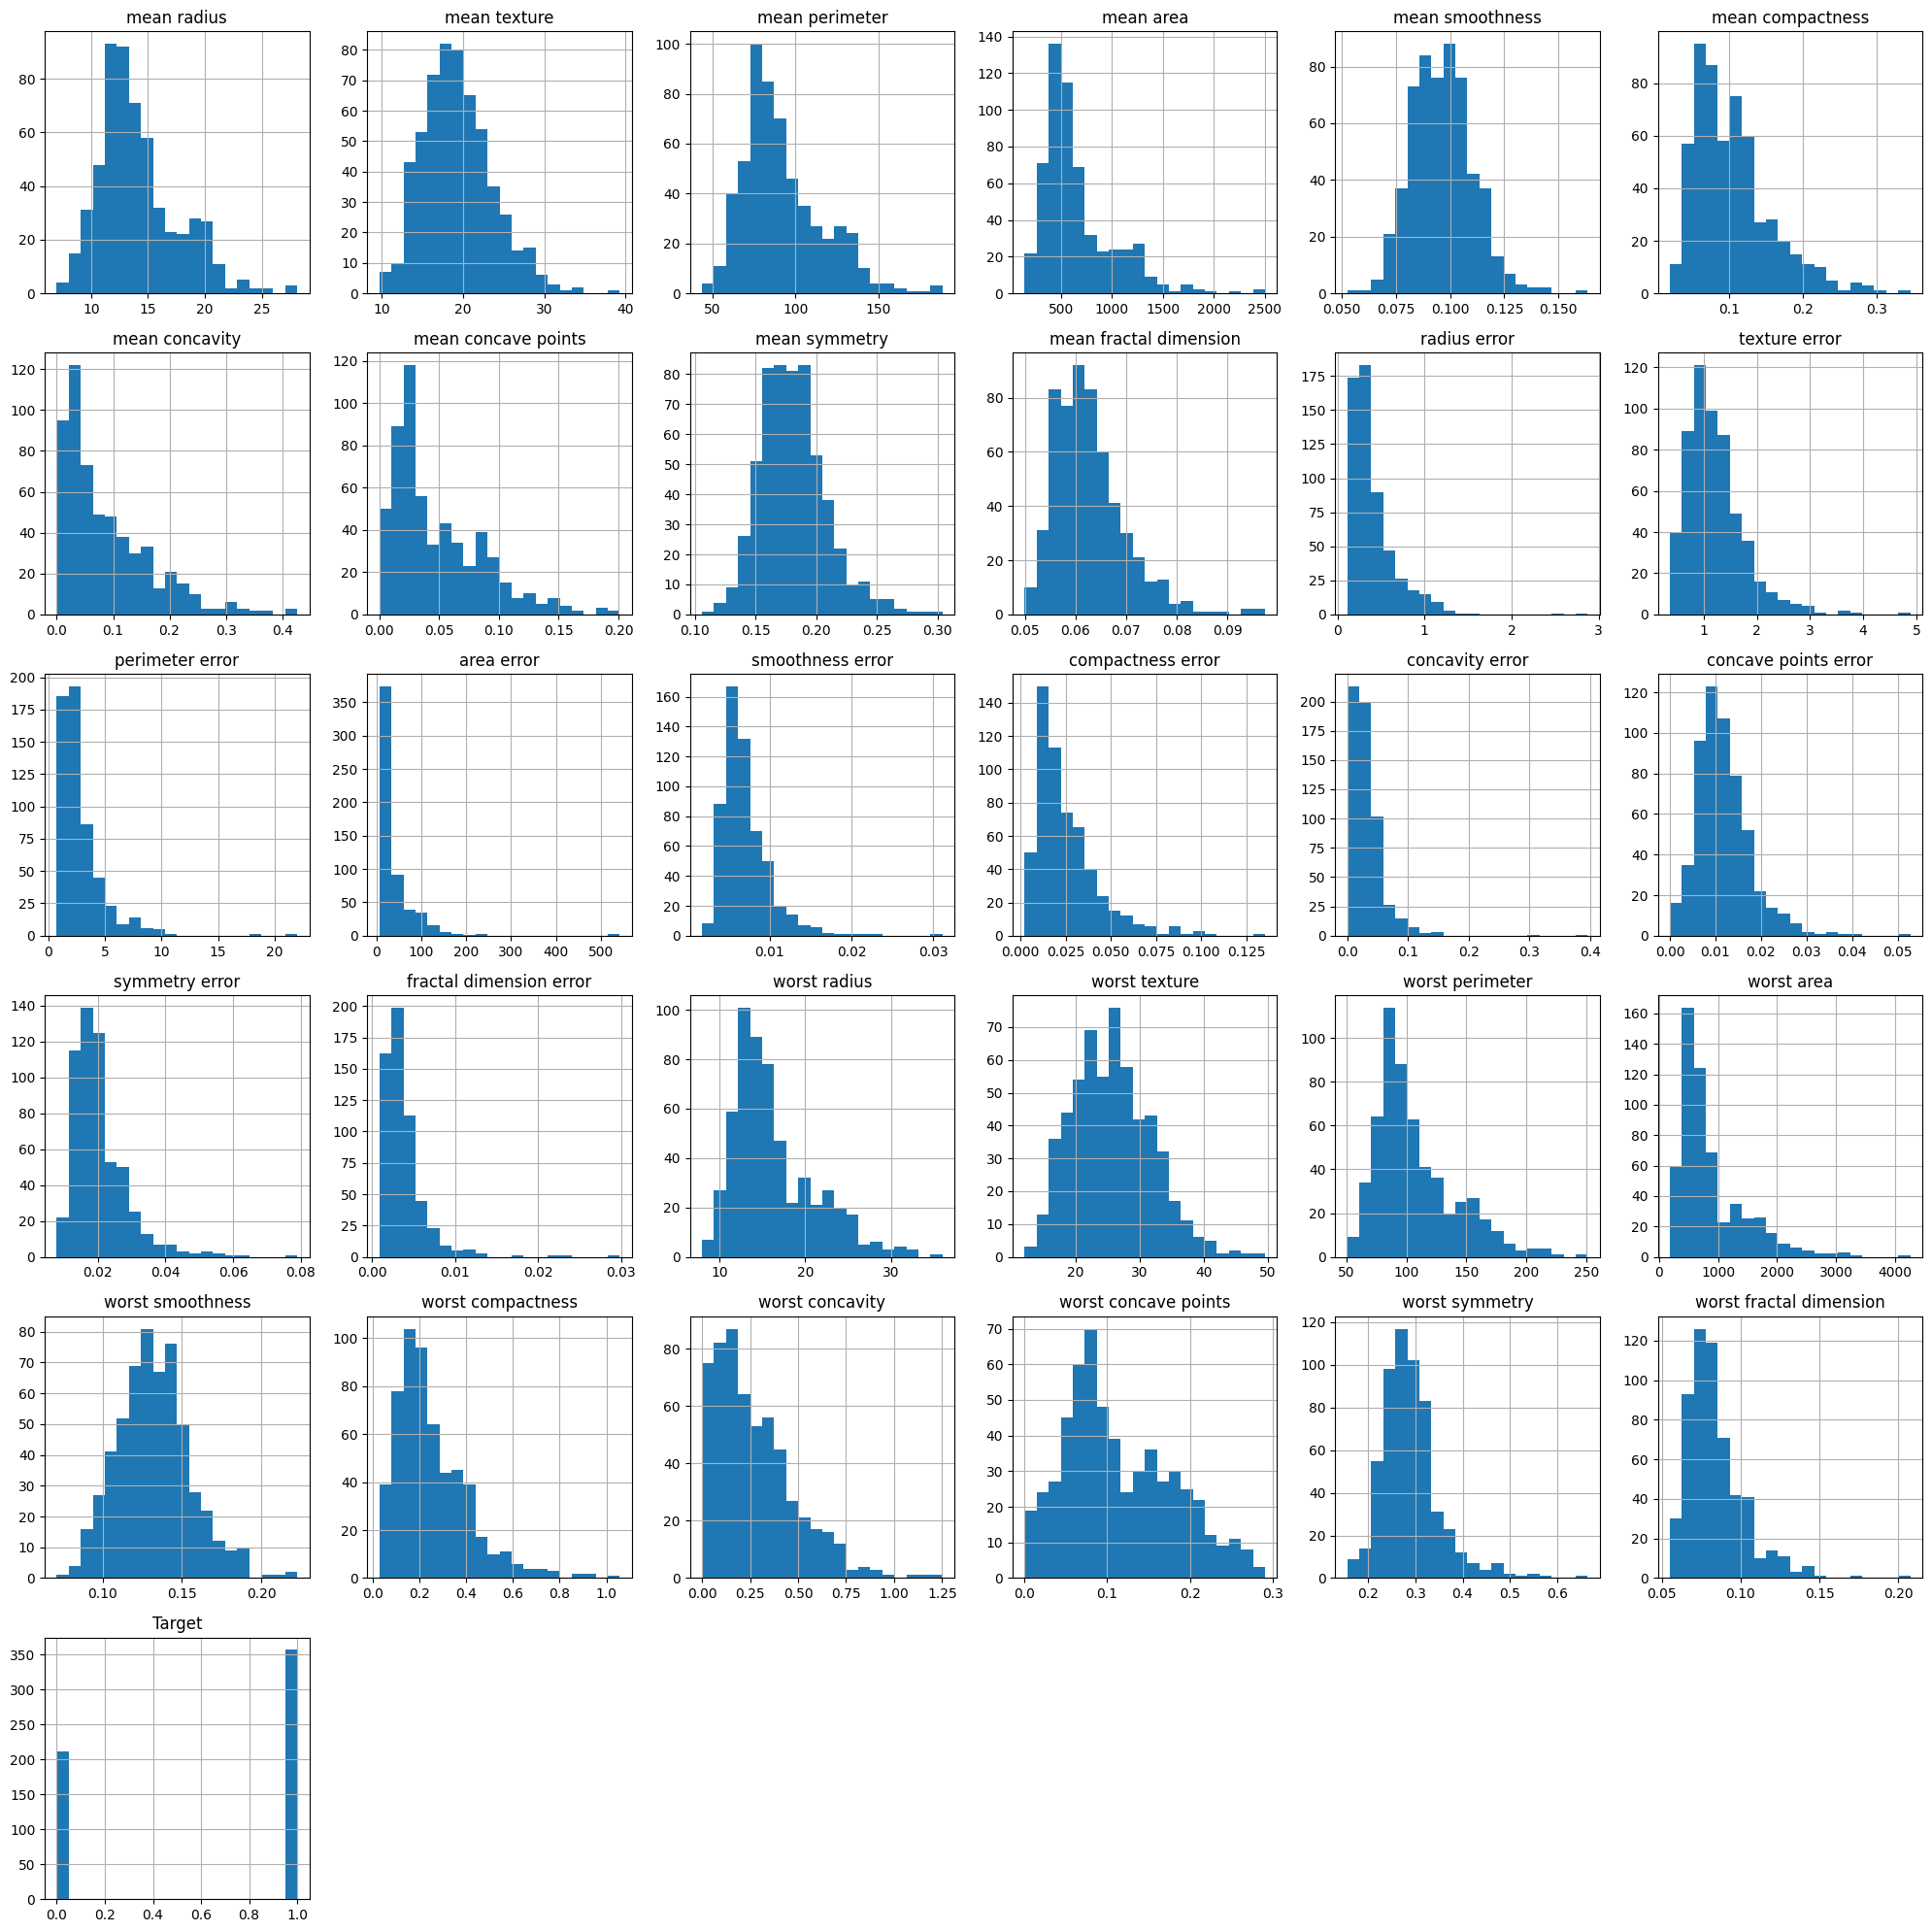

In [15]:

df.hist(figsize=(20,20), bins=20)

plt.tight_layout()

plt.show()

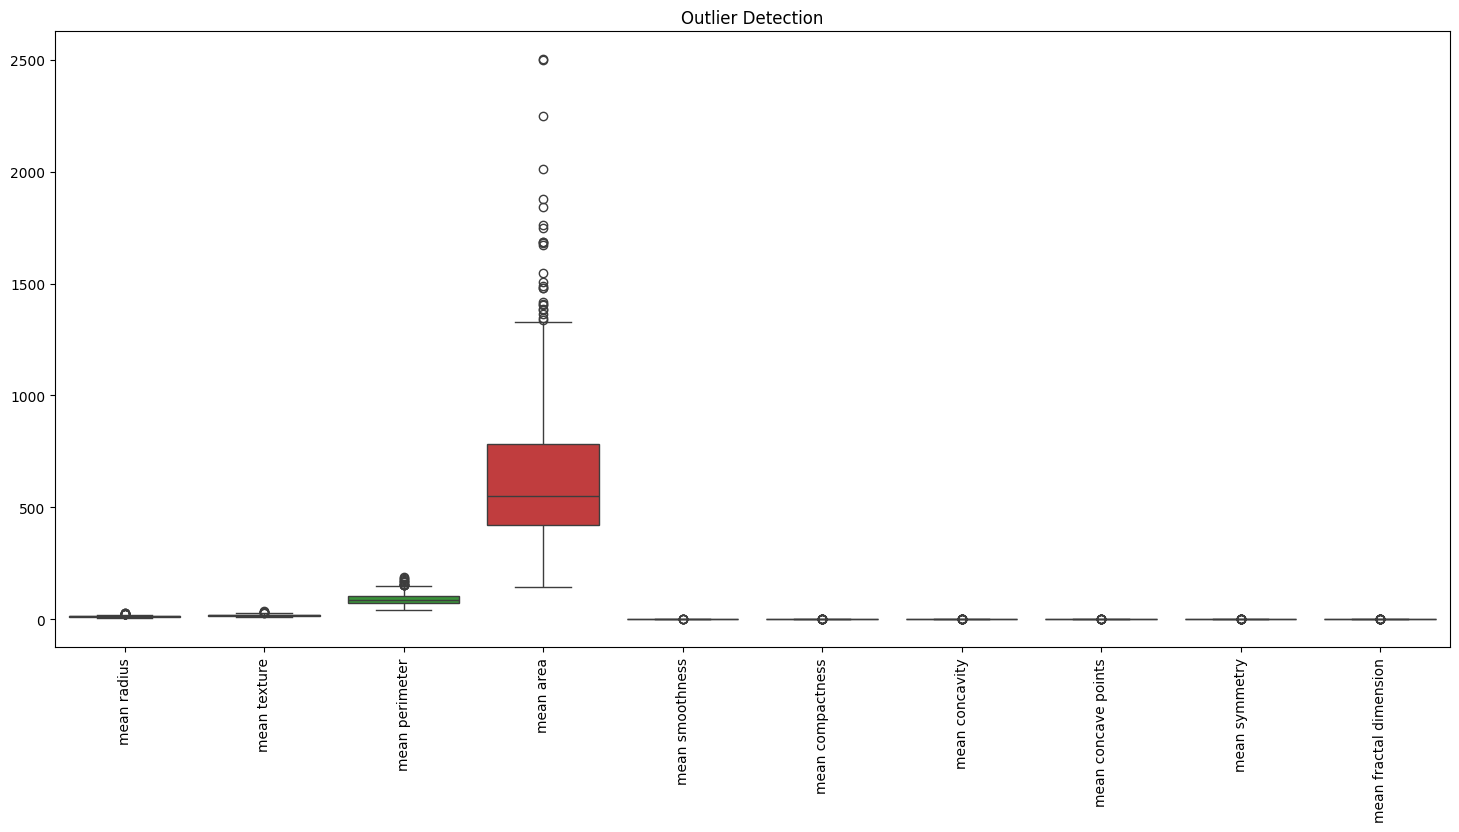

In [16]:
plt.figure(figsize=(18,8))

sns.boxplot(data=df.iloc[:,:10])

plt.xticks(rotation=90)

plt.title("Outlier Detection")

plt.show()

In [17]:


X = df.drop("Target", axis=1)

y = df["Target"]

In [18]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :",X_train.shape)

print("Testing Samples :",X_test.shape)

Training Samples : (455, 30)
Testing Samples : (114, 30)


In [19]:


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [20]:


model = tf.keras.Sequential([

    Dense(64,
          activation='relu',
          input_shape=(30,)),

    BatchNormalization(),

    Dropout(0.30),

    Dense(32,
          activation='relu'),

    BatchNormalization(),

    Dropout(0.25),

    Dense(16,
          activation='relu'),

    Dense(8,
          activation='relu'),

    Dense(1,
          activation='sigmoid')

])

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 4,929 (19.25 KB)

 Non-trainable params: 192 (768.00 B)

In [22]:
model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']

)

In [23]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=15,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=5,

    verbose=1

)

checkpoint = ModelCheckpoint(

    "best_model.keras",

    monitor="val_accuracy",

    save_best_only=True

)

In [24]:
history = model.fit(

    X_train,

    y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=32,

    callbacks=[

        early_stop,

        reduce_lr,

        checkpoint

    ],

    verbose=1

)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.6209 - loss: 0.6685 - val_accuracy: 0.7473 - val_loss: 0.6268 - learning_rate: 0.0010
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8214 - loss: 0.5327 - val_accuracy: 0.8791 - val_loss: 0.5370 - learning_rate: 0.0010
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8929 - loss: 0.4181 - val_accuracy: 0.9451 - val_loss: 0.4571 - learning_rate: 0.0010
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9121 - loss: 0.3503 - val_accuracy: 0.9451 - val_loss: 0.3833 - learning_rate: 0.0010
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9231 - loss: 0.2824 - val_accuracy: 0.9560 - val_loss: 0.3158 - learning_rate: 0.0010
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9203 - loss: 0.2430 - val_accuracy: 0.9560 - val_loss: 0.2576 - learning_rate: 0.0010
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9533 - loss: 0.1979 - v

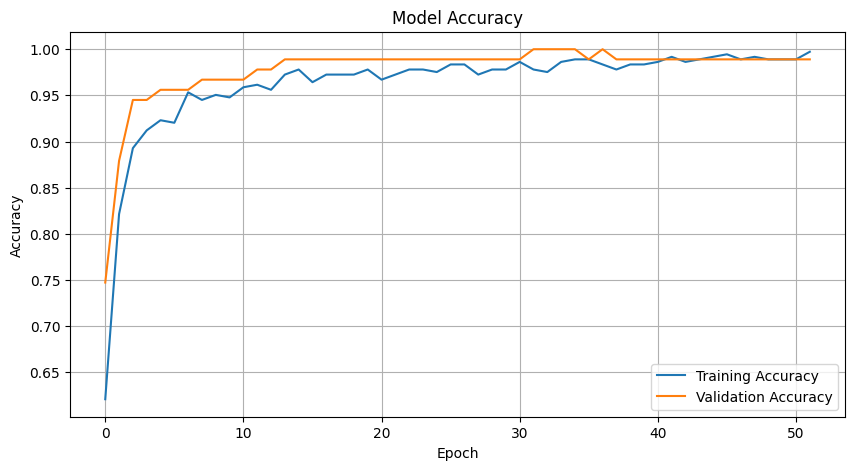

In [25]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'],
         label="Training Accuracy")

plt.plot(history.history['val_accuracy'],
         label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Model Accuracy")

plt.legend()

plt.grid()

plt.show()

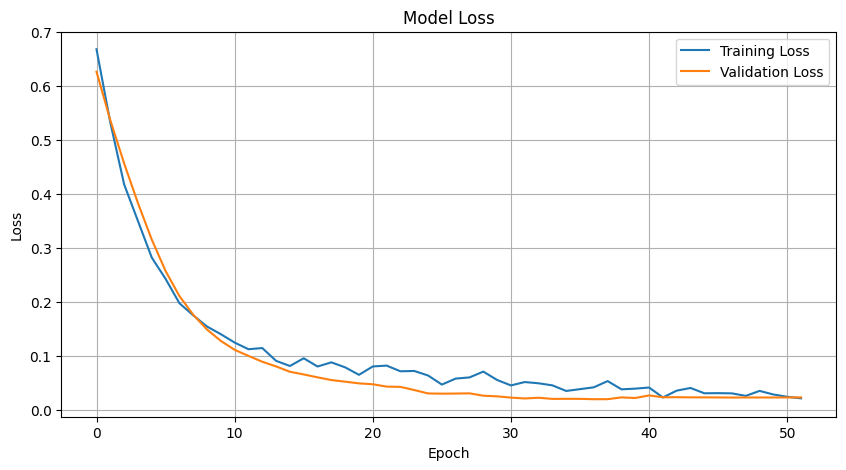

In [26]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],
         label="Training Loss")

plt.plot(history.history['val_loss'],
         label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Model Loss")

plt.legend()

plt.grid()

plt.show()

In [27]:
loss,accuracy = model.evaluate(
    X_test,
    y_test
)

print("Loss :",loss)

print("Accuracy :",accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9561 - loss: 0.1021 
Loss : 0.1020856723189354
Accuracy : 0.9561403393745422


In [28]:
y_prob = model.predict(X_test)

y_pred = (y_prob > 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [29]:
from sklearn.metrics import accuracy_score

print("Accuracy Score")

print(accuracy_score(y_test,y_pred))

Accuracy Score
0.956140350877193


In [30]:
print("Precision :",precision_score(y_test,y_pred))

print("Recall :",recall_score(y_test,y_pred))

print("F1 Score :",f1_score(y_test,y_pred))

Precision : 0.9855072463768116
Recall : 0.9444444444444444
F1 Score : 0.9645390070921985


In [31]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



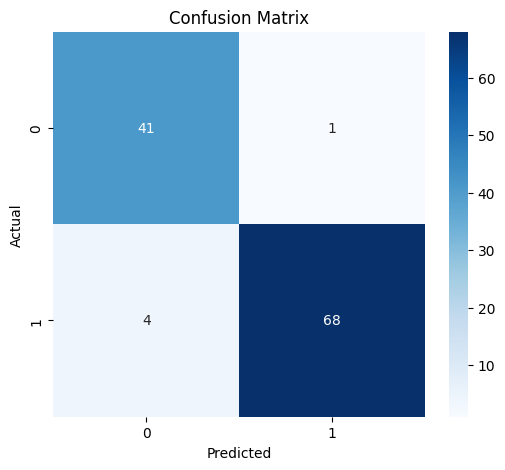

In [32]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


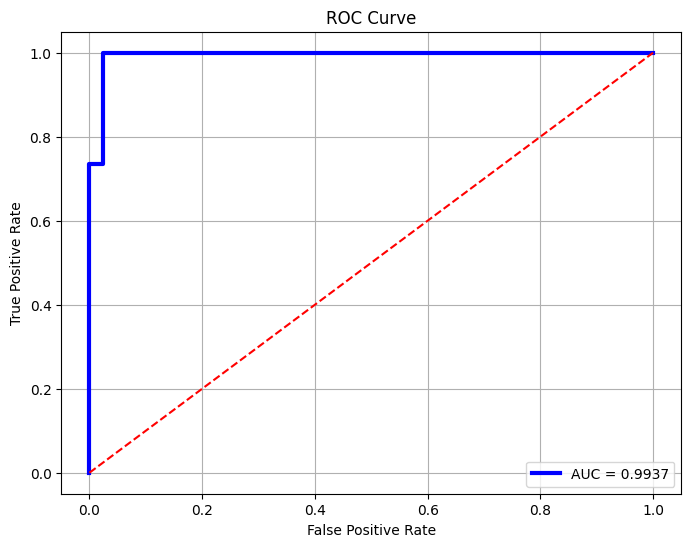

In [33]:


from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

y_probability = model.predict(X_test)

fpr, tpr, threshold = roc_curve(y_test, y_probability)

auc_score = roc_auc_score(y_test, y_probability)

plt.figure(figsize=(8,6))

plt.plot(fpr,
         tpr,
         color="blue",
         linewidth=3,
         label=f"AUC = {auc_score:.4f}")

plt.plot([0,1],[0,1],
         linestyle="--",
         color="red")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

In [34]:
print("="*40)
print("ROC-AUC Score")
print("="*40)

print(auc_score)

ROC-AUC Score
0.9937169312169312


In [35]:
prediction = model.predict(X_test)

prediction = (prediction > 0.5).astype(int)

result = pd.DataFrame({

    "Actual":y_test,

    "Predicted":prediction.flatten()

})

result.head(15)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


,Actual,Predicted
256,0,0
428,1,1
501,0,0
363,1,0
564,0,0
464,1,1
358,1,1
343,0,0
516,0,0
567,0,0


In [36]:
sample = X_test[0].reshape(1,-1)

prediction = model.predict(sample)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[4.0381557e-05]]


In [37]:
if prediction > 0.5:
    print("Prediction : Benign (No Cancer)")
else:
    print("Prediction : Malignant (Cancer)")

Prediction : Malignant (Cancer)


In [38]:
predictions = model.predict(X_test[:10])

predictions = (predictions>0.5).astype(int)

for i in range(10):

    print("="*40)

    print("Patient",i+1)

    print("Actual :",y_test.iloc[i])

    print("Predicted :",predictions[i][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Patient 1
Actual : 0
Predicted : 0
Patient 2
Actual : 1
Predicted : 1
Patient 3
Actual : 0
Predicted : 0
Patient 4
Actual : 1
Predicted : 0
Patient 5
Actual : 0
Predicted : 0
Patient 6
Actual : 1
Predicted : 1
Patient 7
Actual : 1
Predicted : 1
Patient 8
Actual : 0
Predicted : 0
Patient 9
Actual : 0
Predicted : 0
Patient 10
Actual : 0
Predicted : 0


In [39]:
model.save("Breast_Cancer_DNN.keras")

print("Model Saved Successfully")

Model Saved Successfully


In [40]:
from google.colab import files

files.download("Breast_Cancer_DNN.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
from tensorflow.keras.models import load_model

loaded_model = load_model("Breast_Cancer_DNN.keras")

print("Model Loaded Successfully")

Model Loaded Successfully


In [42]:
prediction = loaded_model.predict(sample)

if prediction > 0.5:

    print("Benign")

else:

    print("Malignant")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Malignant


In [43]:
prediction = model.predict(X_test)

prediction = (prediction>0.5).astype(int)

prediction[:20]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


array([[0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1]])

In [44]:
comparison = pd.DataFrame({

    "Actual":y_test.values,

    "Predicted":prediction.flatten()

})

comparison.head(20)

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,1,0
4,0,0
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0


In [45]:
wrong = comparison[comparison.Actual!=comparison.Predicted]

wrong

,Actual,Predicted
3,1,0
16,1,0
38,1,0
51,1,0
53,0,1


In [46]:
print("Wrong Predictions :",len(wrong))

Wrong Predictions : 5


In [47]:
correct = comparison[comparison.Actual==comparison.Predicted]

print("Correct Predictions :",len(correct))

Correct Predictions : 109


In [48]:
accuracy = accuracy_score(y_test,prediction)

print("="*40)

print("Final Accuracy")

print("="*40)

print(round(accuracy*100,2),"%")

Final Accuracy
95.61 %


In [49]:
print("="*60)

print("PROJECT SUMMARY")

print("="*60)

print("Training Samples :",len(X_train))

print("Testing Samples :",len(X_test))

print("Features :",X_train.shape[1])

print("Accuracy :",round(accuracy*100,2),"%")

print("Precision :",round(precision_score(y_test,prediction),4))

print("Recall :",round(recall_score(y_test,prediction),4))

print("F1 Score :",round(f1_score(y_test,prediction),4))

print("ROC-AUC :",round(auc_score,4))

print("="*60)

PROJECT SUMMARY
Training Samples : 455
Testing Samples : 114
Features : 30
Accuracy : 95.61 %
Precision : 0.9855
Recall : 0.9444
F1 Score : 0.9645
ROC-AUC : 0.9937
